First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
Epoch 1/100


C:\Users\DEVAPRIYAN\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8436 - mae: 0.6372 - val_loss: 0.4749 - val_mae: 0.4890
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4224 - mae: 0.4602 - val_loss: 0.4217 - val_mae: 0.4584
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3769 - mae: 0.4359 - val_loss: 0.4004 - val_mae: 0.4373
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3676 - mae: 0.4280 - val_loss: 0.3842 - val_mae: 0.4354
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3581 - mae: 0.4206 - val_loss: 0.3870 - val_mae: 0.4435
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3380 - mae: 0.4101 - val_loss: 0.3767 - val_mae: 0.4225
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3367 - mae: 0.4072 - val_loss: 0.3553 - val_mae: 0.4187
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3264 - mae: 0.4009 - val_loss: 0.3811 - val_mae: 0.4185
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss:

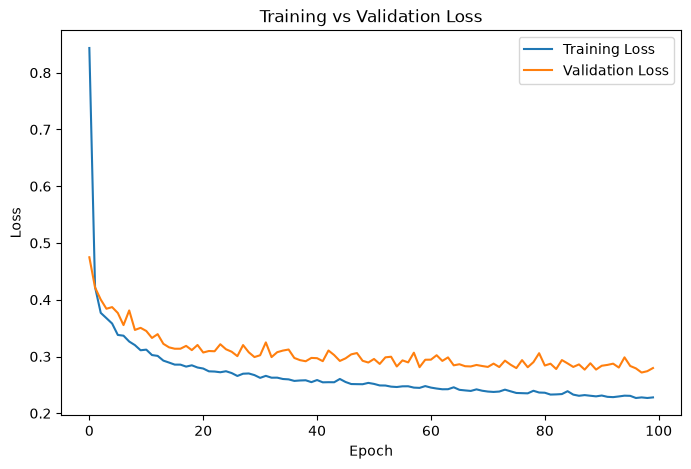

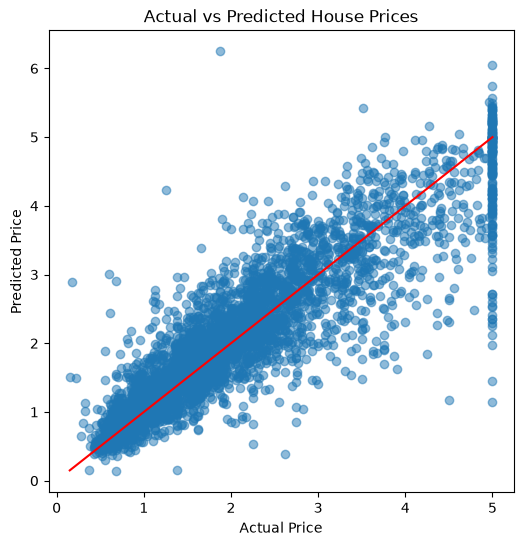

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

housing = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df["Price"] = y

print("First 5 Rows:")
print(df.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("------------------------------")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()